In [ ]:
import warnings
warnings.filterwarnings('ignore')

import zipfile
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import helper_functions as fx

In [3]:
file_path = '/Volumes/SEAGATE/FX_data/FX_histdata/'
fx_pairs = ["EURUSD", "EURGBP", "USDJPY", "GBPUSD", "USDCHF", "USDCAD", "AUDUSD", "NZDUSD", "EURJPY", "GBPJPY", "EURCHF", "AUDJPY", "EURAUD", "GBPAUD"]

In [4]:
# fx.unzip_histdata(file_path, fx_pairs)
# fx.create_parquet_files(file_path, fx_pairs)

In [5]:
eurusd = pd.read_parquet(os.path.join(file_path, f"{fx_pairs[0]}/", f"{fx_pairs[0]}_merged_1M.parquet"))
display(eurusd.head())
display(eurusd.info())

,DateTime,Open,High,Low,Close
0,2023-01-01 17:04:00,1.06970,1.06974,1.06970,1.06970
1,2023-01-01 17:05:00,1.06973,1.06978,1.06970,1.06971
2,2023-01-01 17:06:00,1.06966,1.06966,1.06966,1.06966
3,2023-01-01 17:08:00,1.06970,1.06974,1.06970,1.06974
4,2023-01-01 17:10:00,1.06975,1.06980,1.06972,1.06972


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7833311 entries, 0 to 7833310
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   DateTime  datetime64[ns]
 1   Open      float64       
 2   High      float64       
 3   Low       float64       
 4   Close     float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 298.8 MB


None

<Axes: title={'center': 'Count of Equal Values in Columns'}>

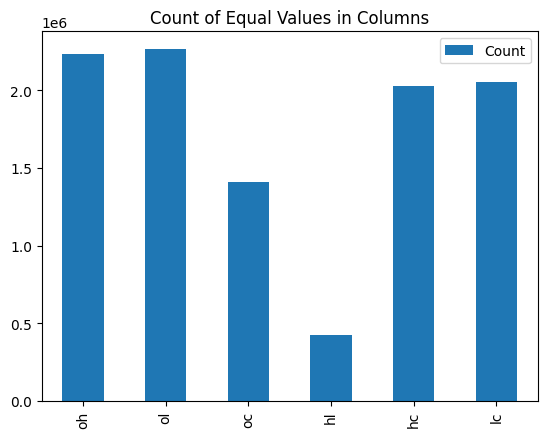

In [6]:
#pivot table comparing values equal in the columns
check_counts = pd.DataFrame(index=['oh', 'ol', 'oc', 'hl', 'hc', 'lc'], columns=['Count'])
check_counts.loc['oh', 'Count'] = (eurusd['Open'] == eurusd['High']).sum()
check_counts.loc['ol', 'Count'] = (eurusd['Open'] == eurusd['Low']).sum()
check_counts.loc['oc', 'Count'] = (eurusd['Open'] == eurusd['Close']).sum()
check_counts.loc['hl', 'Count'] = (eurusd['High'] == eurusd['Low']).sum()
check_counts.loc['hc', 'Count'] = (eurusd['High'] == eurusd['Close']).sum()
check_counts.loc['lc', 'Count'] = (eurusd['Low'] == eurusd['Close']).sum()
check_counts.plot(kind='bar', title='Count of Equal Values in Columns')

In [7]:
close_price_distribution = eurusd['Close'].value_counts(bins=50).sort_index()
print(close_price_distribution)
neg_price_distribution = eurusd[eurusd['Close'] <= 0]
print(neg_price_distribution.info())

(-1.966, 39.3]      7833310
(39.3, 78.6]              0
(78.6, 117.9]             0
(117.9, 157.2]            0
(157.2, 196.5]            0
(196.5, 235.8]            0
(235.8, 275.1]            0
(275.1, 314.4]            0
(314.4, 353.7]            0
(353.7, 393.0]            0
(393.0, 432.3]            0
(432.3, 471.6]            0
(471.6, 510.9]            0
(510.9, 550.2]            0
(550.2, 589.5]            0
(589.5, 628.8]            0
(628.8, 668.1]            0
(668.1, 707.4]            0
(707.4, 746.7]            0
(746.7, 786.0]            0
(786.0, 825.3]            0
(825.3, 864.6]            0
(864.6, 903.9]            0
(903.9, 943.2]            0
(943.2, 982.5]            0
(982.5, 1021.8]           0
(1021.8, 1061.1]          0
(1061.1, 1100.4]          0
(1100.4, 1139.7]          0
(1139.7, 1179.0]          0
(1179.0, 1218.3]          0
(1218.3, 1257.6]          0
(1257.6, 1296.9]          0
(1296.9, 1336.2]          0
(1336.2, 1375.5]          0
(1375.5, 1414.8]    

In [10]:
eurusd = fx.replace_neg_prices(eurusd)
eurusd = fx.replace_high_prices(eurusd, threshold=eurusd['Close'].quantile(0.99))

Replacing 1 rows with non-positive close prices with 0
Replacing 1 rows with close prices above 3.1232 with 1.5616


In [11]:
#print all duplicate DateTime entries and their counts and indexes
duplicate_datetimes = eurusd[eurusd.duplicated(subset=['DateTime'], keep=False)]
print(duplicate_datetimes['DateTime'].value_counts())

DateTime
2023-10-29 19:00:00    2
2021-10-31 19:26:00    2
2021-10-31 19:24:00    2
2021-10-31 19:23:00    2
2021-10-31 19:22:00    2
                      ..
2019-10-27 19:39:00    2
2019-10-27 19:38:00    2
2019-10-27 19:37:00    2
2019-10-27 19:36:00    2
2022-10-30 19:59:00    2
Name: count, Length: 300, dtype: int64


In [12]:
print(eurusd.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7833311 entries, 0 to 7833310
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   DateTime  datetime64[ns]
 1   Open      float64       
 2   High      float64       
 3   Low       float64       
 4   Close     float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 298.8 MB
None


In [13]:
eurusd = fx.drop_duplicate_datetimes(eurusd)

Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry


In [14]:
# Set datetime as index
eurusd.set_index('DateTime', inplace=True)

<Axes: title={'center': 'Close Prices for EURUSD'}, xlabel='DateTime'>

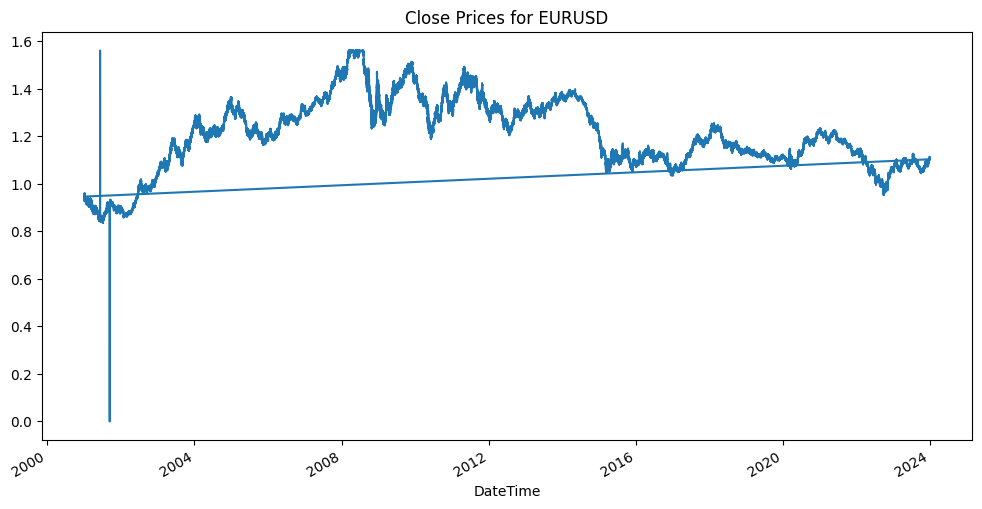

In [15]:
eurusd['Close'].plot(kind='line', title='Close Prices for EURUSD', figsize=(12, 6))

Notice the spikes upward and downward due to abnormal bid prices greater than threshold (2*99th percentile) and below 0, respectively clipped at 99th percentile and 0.

In [21]:
eurusd.sort_index(inplace=True)

In [22]:
print(eurusd.head(20))
print(eurusd.info())

                       Open    High     Low   Close
DateTime                                           
2001-01-02 04:17:00  0.9470  0.9470  0.9470  0.9470
2001-01-02 04:18:00  0.9469  0.9469  0.9467  0.9469
2001-01-02 04:19:00  0.9471  0.9471  0.9468  0.9468
2001-01-02 04:20:00  0.9467  0.9467  0.9467  0.9467
2001-01-02 04:21:00  0.9468  0.9469  0.9468  0.9469
2001-01-02 04:22:00  0.9469  0.9470  0.9469  0.9470
2001-01-02 04:23:00  0.9471  0.9477  0.9471  0.9472
2001-01-02 04:24:00  0.9473  0.9473  0.9472  0.9473
2001-01-02 04:25:00  0.9471  0.9471  0.9468  0.9468
2001-01-02 04:26:00  0.9466  0.9466  0.9465  0.9466
2001-01-02 04:27:00  0.9465  0.9465  0.9463  0.9464
2001-01-02 04:28:00  0.9465  0.9465  0.9464  0.9465
2001-01-02 04:29:00  0.9464  0.9465  0.9464  0.9465
2001-01-02 04:30:00  0.9466  0.9466  0.9466  0.9466
2001-01-02 04:31:00  0.9467  0.9467  0.9465  0.9465
2001-01-02 04:32:00  0.9466  0.9466  0.9465  0.9465
2001-01-02 04:33:00  0.9463  0.9464  0.9462  0.9462
2001-01-02 0

In [24]:
resampled_df = eurusd.resample('5T', label='right', closed='right').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'})
print(resampled_df.head())

                       Open    High     Low   Close
DateTime                                           
2001-01-02 04:20:00  0.9470  0.9471  0.9467  0.9467
2001-01-02 04:25:00  0.9468  0.9477  0.9468  0.9468
2001-01-02 04:30:00  0.9466  0.9466  0.9463  0.9466
2001-01-02 04:35:00  0.9467  0.9467  0.9460  0.9461
2001-01-02 04:40:00  0.9460  0.9460  0.9455  0.9457


In [27]:
eurusd_resampled = pd.read_parquet(os.path.join(file_path, f"{fx_pairs[0]}/", f"{fx_pairs[0]}_resampled_5T.parquet"))
print(eurusd_resampled.head())

                       Open    High     Low   Close
DateTime                                           
2001-01-02 04:20:00  0.9470  0.9471  0.9467  0.9467
2001-01-02 04:25:00  0.9468  0.9477  0.9468  0.9468
2001-01-02 04:30:00  0.9466  0.9466  0.9463  0.9466
2001-01-02 04:35:00  0.9467  0.9467  0.9460  0.9461
2001-01-02 04:40:00  0.9460  0.9460  0.9455  0.9457


In [29]:
eurusd_returns = pd.read_parquet(os.path.join(file_path, f"{fx_pairs[0]}/", f"{fx_pairs[0]}_resampled_5T_returns.parquet"))
display(eurusd_returns.head())

,Open,High,Low,Close,Return,logReturn,target
DateTime,,,,,,,
2001-01-02 04:20:00,0.9470,0.9471,0.9467,0.9467,NaN,NaN,0.000106
2001-01-02 04:25:00,0.9468,0.9477,0.9468,0.9468,0.000106,0.000106,-0.000211
2001-01-02 04:30:00,0.9466,0.9466,0.9463,0.9466,-0.000211,-0.000211,-0.000528
2001-01-02 04:35:00,0.9467,0.9467,0.9460,0.9461,-0.000528,-0.000528,-0.000423
2001-01-02 04:40:00,0.9460,0.9460,0.9455,0.9457,-0.000423,-0.000423,0.000000
